# 1. Stellar surfaces in spherical harmonics

This tutorial introduces the surface representation used throughout
**jittermap**, following Section 2 of Taaki, Corrales & Hero (2026),
[arXiv:2601.11737](https://arxiv.org/abs/2601.11737).

A stellar surface brightness map $s(\theta, \phi)$ is expanded in complex
spherical harmonics,

$$ s(\theta,\phi) = \sum_{l=0}^{L}\sum_{m=-l}^{l} s_l^m\, Y_l^m(\theta,\phi), $$

truncated at a maximum degree $L$ set by the measurement sensitivity. The
coefficients live in a flat vector with linear index $(l,m) \to l^2+l+m$.
The surface is physically real, which the complex coefficients encode via
the conjugate symmetry $s_l^{-m} = (-1)^m (s_l^m)^*$.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import jittermap as jm


## A single starspot

Circular starspots (spherical caps) have an analytic harmonic expansion: a
cap at the pole has only $m=0$ terms (an integral of Legendre polynomials),
and a Wigner-d rotation places it at any latitude and longitude. No pixel
grids or external tools are involved.

In [2]:
L = 20
s_spot = jm.generate_spot(lat_deg=25, lon_deg=315, radius_deg=15,
                          l_max=L, contrast=0.8, include_background=True)
print("coefficient vector length:", s_spot.shape, "=", f"(L+1)^2 = {(L+1)**2}")

coefficient vector length: (441,) = (L+1)^2 = 441


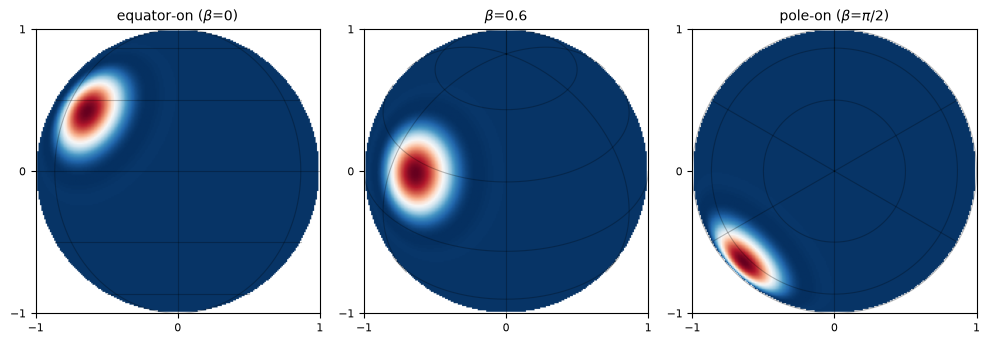

In [3]:
from jittermap.plotting.render import build_projection_grid, render_surface_fast
from jittermap.plotting.panels import render_panel, normalize_map

X, Y, Z, THETA, PHI, mask = build_projection_grid(n_grid=200)

fig, axes = plt.subplots(1, 3, figsize=(10, 3.4))
for ax, beta, label in zip(axes, [0.0, 0.6, np.pi/2],
                           ["equator-on ($\\beta$=0)", "$\\beta$=0.6",
                            "pole-on ($\\beta$=$\\pi$/2)"]):
    m = render_surface_fast(s_spot, L, beta, THETA, PHI, mask, X, Y, Z)
    render_panel(ax, normalize_map(m), label, beta)
plt.tight_layout()

The same surface viewed at three inclinations. In jittermap's convention
$\beta = 0$ means the observer faces the **equator** and $\beta = \pi/2$
the **pole** (paper Fig. 1). Dark spots are drawn in red.

## Multi-spot surfaces with small-scale texture

`multispot_surface` sums several caps and can add a Gaussian random surface
whose per-degree power follows the GMRF prior power law — emulating
variation from smaller, unresolved active regions.

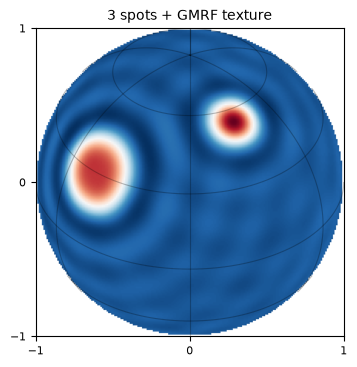

In [4]:
spots = [(30, 315, 14.0), (55, 30, 9.0), (-10, 250, 11.0)]
s_multi = jm.multispot_surface(spots, l_max=L, texture_amplitude=0.004,
                               texture_seed=1)
m = render_surface_fast(s_multi, L, 0.6, THETA, PHI, mask, X, Y, Z)
fig, ax = plt.subplots(figsize=(4, 4))
render_panel(ax, normalize_map(m), "3 spots + GMRF texture", 0.6)

## The GMRF random surface and its power spectrum

`random_surface(l_max, alpha, scale)` draws coefficients with per-degree
variance $(\mathrm{scale}/l)^\alpha$ and real-surface symmetry. This same
power law is used as the prior precision in MAP inversion
(Tutorial 4).

<>:7: SyntaxWarning: invalid escape sequence '\,'
<>:7: SyntaxWarning: invalid escape sequence '\,'
/tmp/ipykernel_136307/3000236424.py:7: SyntaxWarning: invalid escape sequence '\,'
  label="expected $(2l+1)\,\mathrm{scale}/l$")


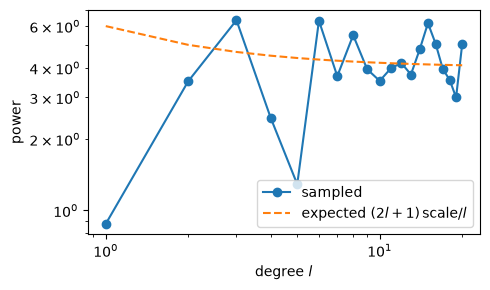

In [5]:
sh = jm.SHIndexer(L)
s_rand = jm.random_surface(L, alpha=1.0, scale=2.0, seed=0)
power = [np.sum(np.abs(s_rand[sh.get_l_indices(l)])**2) for l in range(1, L+1)]
plt.figure(figsize=(5, 3))
plt.loglog(range(1, L+1), power, "o-", label="sampled")
plt.loglog(range(1, L+1), [(2*l+1)*2.0/l for l in range(1, L+1)], "--",
           label="expected $(2l+1)\,\mathrm{scale}/l$")
plt.xlabel("degree $l$"); plt.ylabel("power"); plt.legend(); plt.tight_layout()

## Spot sizes

Paper figures quote spot radii as a fraction of the stellar radius
$R_\mathrm{spot}/R_\star$; `rfrac_to_deg` converts to the angular cap
radius, and `spot_area_fraction` gives the covered fraction of the sphere.

In [6]:
for rfrac in [0.05, 0.10, 0.25]:
    deg = jm.rfrac_to_deg(rfrac)
    print(f"R_spot/R_star = {rfrac:.2f} -> cap radius {deg:5.1f} deg, "
          f"area fraction {jm.spot_area_fraction(deg):.4f}")

R_spot/R_star = 0.05 -> cap radius   5.7 deg, area fraction 0.0025
R_spot/R_star = 0.10 -> cap radius  11.5 deg, area fraction 0.0100
R_spot/R_star = 0.25 -> cap radius  29.0 deg, area fraction 0.0625
